<a href="https://colab.research.google.com/github/yusuf-codes10/deep-learining-project/blob/main/testing_modela.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data initialization

In [1]:
# STEP 1 — Set Kaggle credentials (run this first)
import os
from getpass import getpass

os.environ['KAGGLE_USERNAME'] = input("Enter Kaggle username: ")
os.environ['KAGGLE_API_TOKEN'] = getpass("Enter Kaggle API key: ")

Enter Kaggle username: youcefcopy
Enter Kaggle API key: ··········


In [2]:
# STEP 2 — Install Kaggle (run once per session)
!pip install -q kaggle

In [3]:
# STEP 3 — Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:23<00:00, 103MB/s]



In [4]:
# STEP 4 — Unzip dataset
!unzip -q chest-xray-pneumonia.zip

# Laoding the models

In [5]:


# check the folder strucutre
import os

base_path = "chest_xray"

for split in ['train', 'val', 'test']:
    print(f"\n{split.upper()} FOLDER:")
    for label in os.listdir(os.path.join(base_path, split)):
        count = len(os.listdir(os.path.join(base_path, split, label)))
        print(f"  {label}: {count} images")



TRAIN FOLDER:
  NORMAL: 1341 images
  PNEUMONIA: 3875 images

VAL FOLDER:
  NORMAL: 8 images
  PNEUMONIA: 8 images

TEST FOLDER:
  NORMAL: 234 images
  PNEUMONIA: 390 images


In [7]:
# ── 1. Mount & setup ──────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

Mounted at /content/drive


In [17]:
# ── 2. Load models ────────────────────────────────────────────────────
MODEL_DIR = '/content/drive/MyDrive/my_models'  # underscore, and MyDrive not just drive

cnn_model      = load_model(os.path.join(MODEL_DIR, 'perfect_cnn_v3.h5'))
transfer_model = load_model(os.path.join(MODEL_DIR, 'vgg16_transfer_final_v2.h5'))

print("CNN input:      ", cnn_model.input_shape)
print("Transfer input: ", transfer_model.input_shape)

CNN input:       (None, 64, 64, 3)
Transfer input:  (None, 128, 128, 3)


In [13]:
# listing the folder
import os

model_dir = '/content/drive/MyDrive/my_models'
for f in os.listdir(model_dir):
    print(f)

ann_final.h5
perfect_cnn_v3.h5
vgg16_transfer_final_v2.h5


In [18]:
# ── 3. Load test set at two sizes ─────────────────────────────────────
TEST_DIR = '/content/chest_xray/test'   # adjust if your dataset is on Drive

def load_test(test_dir, img_size):
    images, labels = [], []
    for label, class_idx in [('NORMAL', 0), ('PNEUMONIA', 1)]:
        folder = os.path.join(test_dir, label)
        for fname in sorted(os.listdir(folder)):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            img = image.load_img(os.path.join(folder, fname), target_size=img_size)
            images.append(image.img_to_array(img) / 255.0)
            labels.append(class_idx)
    return np.array(images), np.array(labels)

print("Loading 64x64  (CNN)...")
X_test_64,  y_test = load_test(TEST_DIR, (64, 64))

print("Loading 128x128 (Transfer)...")
X_test_128, _      = load_test(TEST_DIR, (128, 128))

print(f"\nDone — {len(y_test)} images | NORMAL={sum(y_test==0)} | PNEUMONIA={sum(y_test==1)}")

Loading 64x64  (CNN)...
Loading 128x128 (Transfer)...

Done — 624 images | NORMAL=234 | PNEUMONIA=390


In [19]:
# ── 4. Predict ────────────────────────────────────────────────────────
cnn_preds      = (cnn_model.predict(X_test_64)            > 0.5   ).astype(int).flatten()
transfer_preds = (transfer_model.predict(X_test_128)      > 0.9993).astype(int).flatten()

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 107ms/step
20/20 ━━━━━━━━━━━━━━━━━━━━ 80s 4s/step


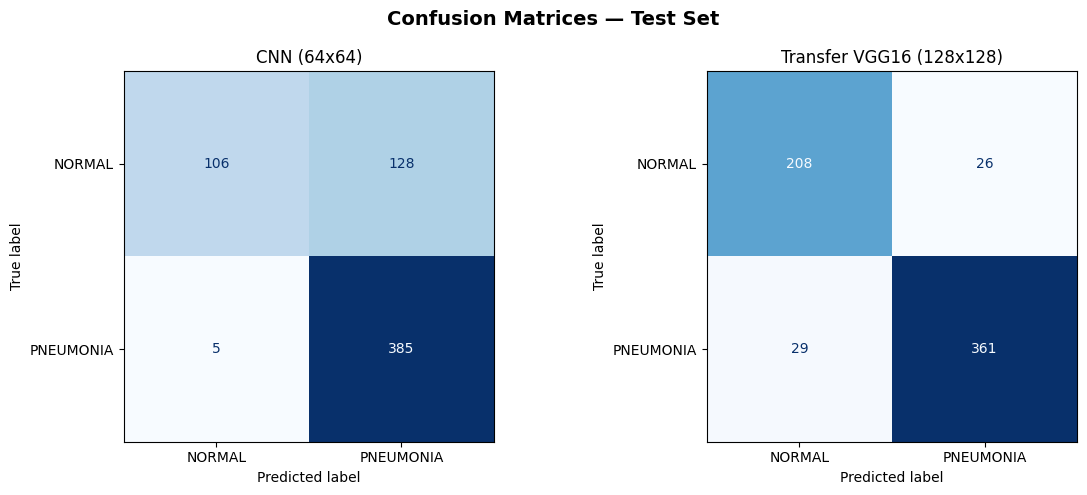

In [20]:
# ── 5. Side-by-side confusion matrices ───────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')

for ax, preds, title in zip(
    axes,
    [cnn_preds,   transfer_preds],
    ['CNN (64x64)', 'Transfer VGG16 (128x128)']
):
    cm = confusion_matrix(y_test, preds)
    ConfusionMatrixDisplay(cm, display_labels=['NORMAL', 'PNEUMONIA']).plot(
        cmap='Blues', ax=ax, colorbar=False
    )
    ax.set_title(title, fontsize=12)

plt.tight_layout()
plt.show()